Transmitter

In [1]:
%load_ext autoreload
%autoreload 2


In [2]:

import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt
from fda_rof_funcs_v1 import(
    qpskmod_with_qammod, crmapping, giins,
    DAParam, tx_fda_pipeline, plotRxSpectrum_2
)




In [34]:
para           = 256
fftlen         = 256
nd             = 40
ml             = 6
sr             = 250e3

OFDM_bandwidth = 5e9

AwgSampleRate  = 120e9
gilen          = 32
roll           = 0.1
order          = 64       # FilterSpanInSymbols
sps            = 8

Rt             = 4.5
G              = 2e9
k_power        = 1.4

para_N1 = DAParam(a=4, b=1.0)
para_N2 = DAParam(a=3, b=1.8)


In [35]:
mat = loadmat("parabits.mat")
parabits = mat["parabits"].astype(np.int64).reshape(-1)  # column vector -> 1D

# MATLAB: paradata = reshape(parabits, para, nd*ml)  (column-major!)
paradata = parabits.reshape((para, nd * ml), order="F")

QAM_I, QAM_Q = qpskmod_with_qammod(paradata, para=para, nd=nd, ml=ml)

# Your MATLAB normalization
QAM_I_norm = QAM_I / np.sqrt(42)
QAM_Q_norm = QAM_Q / np.sqrt(42)


In [36]:
xI, xQ = crmapping(QAM_I_norm, QAM_Q_norm, fftlen=fftlen, nd=nd)
x = xI + 1j * xQ

# MATLAB: y = ifft(x, fftlen, 1)  (along rows dimension)
y = np.fft.ifft(x, n=fftlen, axis=0)

ich_cp, qch_cp = giins(np.real(y), np.imag(y), fftlen=fftlen, gilen=gilen, nd=nd)
Signal_gi = ich_cp + 1j * qch_cp  # shape: (fftlen+gilen, nd)

# MATLAB: Signal_serial = reshape(Signal_gi, fftlen2*nd, 1) (column-major)
Signal_OFDM = Signal_gi.reshape((-1,), order="F")  # 1D complex


In [37]:
I_awg, Q_awg, Stx_Sig, meta = tx_fda_pipeline(
    Signal_OFDM=Signal_OFDM,
    Rt=Rt,
    OFDM_bandwidth=OFDM_bandwidth,
    para_N1=para_N1,
    para_N2=para_N2,
    roll=roll,
    span=order,
    sps=sps,
    G=G,
    k_power=k_power,
    AwgSampleRate=AwgSampleRate,
    export_awg=True,
)

print("TX meta:", meta)
print("Stx_Sig length (base):", len(Stx_Sig))
print("I/Q length (AWG):", len(I_awg), len(Q_awg))

# 写 CSV（两列）
out = np.column_stack([I_awg, Q_awg])
np.savetxt(f"OFDM_Rt_{Rt:.2f}.csv", out, delimiter=",", header="I,Q", comments="")


TX meta: {'Rt': 4.5, 'p': 0.5, 'q': 0.5, 'N1': 3, 'N2': 4, 'B0': 5000000000.0, 'B1': 10000000000.0, 'B2': 12500000000.0, 'Sys_Symbolrate': 12500000000.0, 'Fs_base': 100000000000.0, 'B_inner': 10000000000.0, 'B_outer': 12500000000.0, 'which_inner': 'N1', 'f_inner': 7000000000.0, 'f_outer': 20250000000.0, 'L_base': 231032, 'seg1_len': 5760, 'seg2_len': 5760, 'L_sig_inner': 231032, 'L_sig_outer': 230905}
Stx_Sig length (base): 231032
I/Q length (AWG): 277239 277239


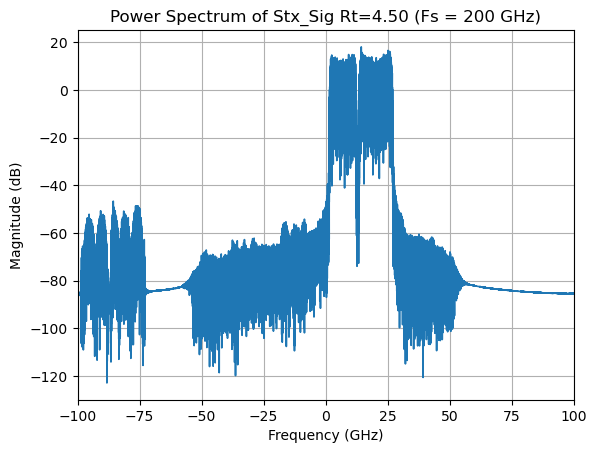

In [38]:
# base-rate spectrum（你的 MATLAB 常用 60e9 来画谱，这里建议先用 Fs_base=meta['Fs_base']）
Fs_base = meta["Fs_base"]
plotRxSpectrum_2(Stx_Sig, Fs=Fs_base*2, SymbolRate=meta["Sys_Symbolrate"], sps=sps, Title=f"Stx_Sig Rt={Rt:.2f}")


Channel

In [76]:
# from fda_rof_funcs import channel_pipeline
# 
# SNR = 20
# rng = np.random.default_rng(0)
# 
# # 等价于你 MATLAB 的 RxSignal = Stx_Sig
# RxSignal, ch_meta = channel_pipeline(Stx_Sig, enable_awgn=False, SNR=SNR, rng=rng)
# 
# # 如果要加 AWGN（等价 awgn(Stx_Sig, SNR, 'measured')）
# # RxSignal, ch_meta = channel_pipeline(Stx_Sig, enable_awgn=True, SNR=SNR, rng=rng)
# 
# print("Channel meta:", ch_meta)
# print("RxSignal len:", len(RxSignal))


Receiver

In [77]:
from fda_rof_funcs_v1 import rx_fda_pipeline_base, Metric_Calculation

# 调用接收端流水线
rx_out = rx_fda_pipeline_base(
    RxSignal=Stx_Sig,
    meta=meta,
    Rt=Rt,
    OFDM_bandwidth=OFDM_bandwidth,
    para_N1=para_N1,
    para_N2=para_N2,
    roll=roll,
    span=order,
    sps=sps,
    G=G,
    k_power=k_power,
    fftlen=fftlen,
    gilen=gilen,
    nd=nd,
    para=para,
    ml=ml,
    L_sig_inner=meta["L_sig_inner"],
    L_sig_outer=meta["L_sig_outer"],
)

# 提取解调后的数据序列
demodata_sequence = rx_out["demodata_sequence"].flatten()

# 计算误码率和SNR6
BER = np.mean(demodata_sequence != parabits)
print(f"BER: {BER:.2e}")
SNR_OFDM = Metric_Calculation(rx_out["Rx_OFDM_Sig"], Signal_OFDM, "OFDM")
#问题：size 变化，SNR计算，和原文对照。

print(f"SNR_OFDM: {SNR_OFDM:.2f} dB")


B2/B1 = 0.5
len rx_n1_shifted = 138745
len rx_n2_shifted = 69625
len rx_n1_rrc     = 138745
len rx_n2_rrc     = 69625
len rx_n1_sym     = 17344
len rx_n2_sym     = 8704
Rx_Signal_N1 len = 17344
Rx_Signal_N2 len = 8704


ValueError: Input length 8704 not divisible by (order+1)=3